len(de) = 1119256
len(dl) = 1119256
len(vlm) = 1119256


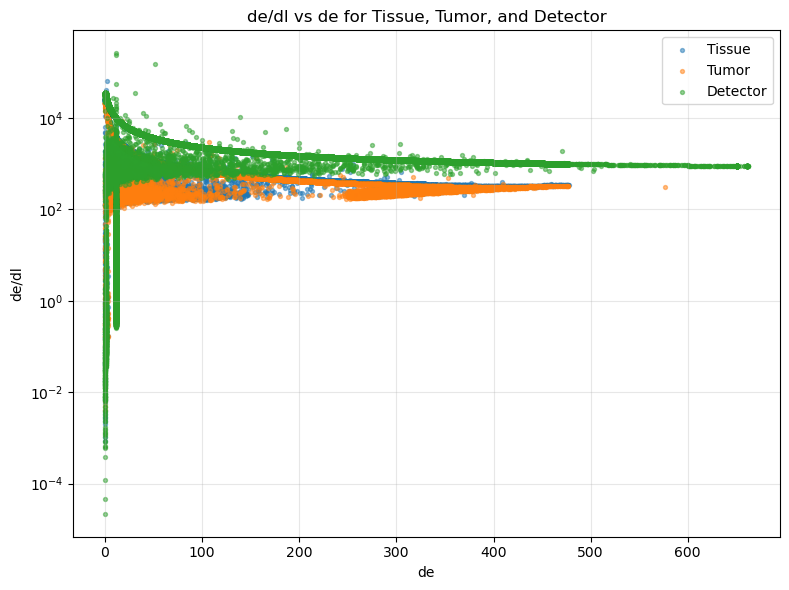

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file_path = "tumor.root"

# Volume labels
vlm_labels = {
    2: "Tissue",
    3: "Tumor",
    6: "Detector"
}

with uproot.open(file_path) as f:
    tree = f["t"]

    de = np.concatenate(tree["de"].array(library="np")).ravel()
    dl = np.concatenate(tree["dl"].array(library="np")).ravel()
    vlm = np.concatenate(tree["vlm"].array(library="np")).ravel()

# safety check
print("len(de) =", len(de))
print("len(dl) =", len(dl))
print("len(vlm) =", len(vlm))

plt.figure(figsize=(8, 6))

for v in [2, 3, 6]:
    mask = (vlm == v) & (dl > 0) & (de > 0)
    
    de_v = de[mask]
    dl_v = dl[mask]
    dedl_v = de_v / dl_v

    plt.scatter(de_v, dedl_v, s=8, alpha=0.5, label=vlm_labels[v])
plt.yscale("log")
plt.xlabel("de")
plt.ylabel("de/dl")
plt.title("de/dl vs de for Tissue, Tumor, and Detector")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()